In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
import re

In [2]:
ruta=''

In [3]:
df = pd.read_csv(ruta+'proveedores2016_2022_nuevas_var_disc_ipc.csv', sep='|')

### definir las variables categóricas y numéricas para que se van a incluir en el análisis

### Armar Dataset

In [4]:
#armar dataset de valores numéricos y categóricos
df_cluster = df[['antiguedad','cant_socios','cant_apercibimientos','cant_suspensiones','cant_antecedentes', 'cant_Apoderado', 'cant_representante','cant_autenticado','cant_noAutenticado','cant_sinMontoLimite','cant_MontoLimite',
'Estado','TipoSocietario','provincia','cant_procesos_adjudicado','monto_total_adjudicado','total_articulos_provee'] ]


### imputar valores

In [ ]:
#En este caso se imputa el valor nulo con 0 porque se interpreta el nulo como que no tiene procesos adjudicados.
df_cluster['cant_procesos_adjudicado'] = df_cluster['cant_procesos_adjudicado'].fillna(0)
#Se imputa nulo con cero porque al no tener proceso adjudicado tampoco monto asociado a ese proceso
df_cluster['monto_total_adjudicado'] = df_cluster['monto_total_adjudicado'].fillna(0)
#Se imputa nulo con -1 para resaltar el hecho de que ese dato no esta completo dado que cero indica que ingresó en 2022.
df_cluster['antiguedad'] = df_cluster['antiguedad'].fillna(-1)
#Se imputa nulo con cero porque indica que no tiene socios
df_cluster['cant_socios'] = df_cluster['cant_socios'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene apercibimientos
df_cluster['cant_apercibimientos'] = df_cluster['cant_apercibimientos'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene suspensiones
df_cluster['cant_suspensiones'] = df_cluster['cant_suspensiones'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene antecedentes
df_cluster['cant_antecedentes'] = df_cluster['cant_antecedentes'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene antecedentes
df_cluster['cant_antecedentes'] = df_cluster['cant_antecedentes'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene apoderado
df_cluster['cant_Apoderado'] = df_cluster['cant_Apoderado'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representante
df_cluster['cant_representante'] = df_cluster['cant_representante'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes autenticados
df_cluster['cant_autenticado'] = df_cluster['cant_autenticado'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes no autenticados
df_cluster['cant_noAutenticado'] = df_cluster['cant_noAutenticado'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes sin monto límite para operar
df_cluster['cant_sinMontoLimite'] = df_cluster['cant_sinMontoLimite'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes con monto límite para operar
df_cluster['cant_MontoLimite'] = df_cluster['cant_MontoLimite'].fillna(0)
#Se imputa nulo con cero porque indica que no tiene representantes con monto límite para operar
df_cluster['cant_MontoLimite'] = df_cluster['cant_MontoLimite'].fillna(0)
#se imputa con cero para indicar que no provee ningún artículo
df_cluster['total_articulos_provee'] = df_cluster['total_articulos_provee'].fillna(0)
df_cluster['provincia'] = df_cluster['provincia'].fillna('sin datos')
df_cluster['Estado'] = df_cluster['Estado'].fillna('sin datos')
df_cluster['TipoSocietario'] = df_cluster['TipoSocietario'].fillna('sin datos')
#df_cluster['dmonto_total_adjudicado'] = df_cluster['dmonto_total_adjudicado'].fillna('sin datos')
#df_cluster['dcant_procesos_adjudicado'] = df_cluster['dcant_procesos_adjudicado'].fillna('sin datos')
#df_cluster['dtotal_articulos_provee'] = df_cluster['dtotal_articulos_provee'].fillna('sin datos')

### Verifica si hay nulos

In [21]:
#ver el % de nulos por variables
total_filas = len(df_cluster)

# Calcular cantidad y porcentaje de nulos por variable
nulos_por_variable = df_cluster.isnull().sum().reset_index()
nulos_por_variable.columns = ['Variable', 'Cantidad de Nulos']
nulos_por_variable['Porcentaje de Nulos (%)'] = (nulos_por_variable['Cantidad de Nulos'] / total_filas) * 100

#pd.set_option('display.max_rows', None)
# Mostrar la tabla
nulos_por_variable

,Variable,Cantidad de Nulos,Porcentaje de Nulos (%)
0,antiguedad,0,0.0
1,cant_socios,0,0.0
2,cant_apercibimientos,0,0.0
3,cant_suspensiones,0,0.0
4,cant_antecedentes,0,0.0
5,cant_Apoderado,0,0.0
6,cant_representante,0,0.0
7,cant_autenticado,0,0.0
8,cant_noAutenticado,0,0.0
9,cant_sinMontoLimite,0,0.0


In [8]:
df_cluster.dtypes


antiguedad                   float64
cant_socios                  float64
cant_apercibimientos         float64
cant_suspensiones            float64
cant_antecedentes            float64
cant_Apoderado               float64
cant_representante           float64
cant_autenticado             float64
cant_noAutenticado           float64
cant_sinMontoLimite          float64
cant_MontoLimite             float64
Estado                        object
TipoSocietario                object
provincia                     object
cant_procesos_adjudicado     float64
monto_total_adjudicado       float64
total_articulos_provee       float64
dmonto_total_adjudicado       object
dcant_procesos_adjudicado     object
dtotal_articulos_provee       object
dtype: object

### 2. Identificar columnas categóricas (por tipo 'object') y numéricas

In [22]:
categorical_cols = df_cluster.select_dtypes(include='object').columns.tolist()
numerical_cols = df_cluster.select_dtypes(include=['float64', 'int64']).columns.tolist()

### 3. Codificar las variables categóricas con LabelEncoder

In [23]:
df_encoded = df_cluster.copy()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))  # convertir a str por si hay NaNs
    #df_encoded[col] = le.fit_transform(df_encoded[col].astype(str)) 
    label_encoders[col] = le  # guardar encoder por si necesitás revertirlo


### 4. Escalar las variables numéricas

In [24]:
scaler = StandardScaler()
df_scaled = df_cluster.copy()
df_encoded[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])
#df_encoded = scaler.fit_transform(df_scaled)

In [25]:
df_encoded

,antiguedad,cant_socios,cant_apercibimientos,cant_suspensiones,cant_antecedentes,cant_Apoderado,cant_representante,cant_autenticado,cant_noAutenticado,cant_sinMontoLimite,cant_MontoLimite,Estado,TipoSocietario,provincia,cant_procesos_adjudicado,monto_total_adjudicado,total_articulos_provee
0,1.225788,-0.819175,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,7,3,4,1.345427,-0.095352,-0.005958
1,1.225788,-0.176440,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,3,8,5,-0.086837,-0.103856,1.077125
2,1.225788,0.466295,7.501256,8.681731,12.814532,1.406325,0.931322,1.510918,1.563411,2.167353,-0.114325,7,7,5,0.265359,-0.100214,0.146996
3,1.225788,-0.176440,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,7,6,5,2.355055,-0.022671,0.056050
4,1.225788,0.466295,-0.114892,-0.092303,-0.125859,-1.157940,0.931322,-0.341377,-0.294027,-0.416749,-0.114325,7,7,1,-0.227716,-0.103172,-0.129976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,-1.844166,-0.819175,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,7,3,1,-0.227716,-0.102641,-0.282930
10072,-1.844166,0.466295,-0.114892,-0.092303,-0.125859,0.124192,0.931322,-0.341377,1.563411,0.875302,-0.114325,7,6,5,-0.227716,-0.085127,-0.262261
10073,-1.844166,1.109031,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-1.708800,5.560261,7,6,5,-0.227716,-0.094609,-0.282930
10074,-0.616185,0.466295,-0.114892,-0.092303,-0.125859,0.124192,-0.730151,-0.341377,-0.294027,-0.416749,-0.114325,7,2,5,-0.227716,-0.111073,-0.208520


In [26]:
# Convertir a matriz de numpy
data_matrix = df_encoded.to_numpy()
cat_indices = [df_encoded.columns.get_loc(col) for col in categorical_cols]
data_matrix

array([[ 1.22578799e+00, -8.19174637e-01, -1.14892271e-01, ...,
         1.34542663e+00, -9.53517832e-02, -5.95838967e-03],
       [ 1.22578799e+00, -1.76439577e-01, -1.14892271e-01, ...,
        -8.68372732e-02, -1.03855571e-01,  1.07712530e+00],
       [ 1.22578799e+00,  4.66295483e-01,  7.50125593e+00, ...,
         2.65358768e-01, -1.00214004e-01,  1.46996177e-01],
       ...,
       [-1.84416622e+00,  1.10903054e+00, -1.14892271e-01, ...,
        -2.27715690e-01, -9.46089113e-02, -2.82930172e-01],
       [-6.16184536e-01,  4.66295483e-01, -1.14892271e-01, ...,
        -2.27715690e-01, -1.11072794e-01, -2.08519843e-01],
       [-1.84416622e+00, -8.19174637e-01, -1.14892271e-01, ...,
        -2.27715690e-01, -1.11111471e-01, -2.70528451e-01]])

In [27]:
# Estimar gamma para balancear las variables numéricas y categóricas y evitar que un tipo de variable domine el clustering
gamma = np.mean(df_encoded[numerical_cols].std()) / len(categorical_cols)

In [28]:
gamma

np.float64(0.3333498755200553)

Entrenando modelo para k=2
Entrenando modelo para k=3
Entrenando modelo para k=4
Entrenando modelo para k=5
Entrenando modelo para k=6
Entrenando modelo para k=7
Entrenando modelo para k=8
Entrenando modelo para k=9
Entrenando modelo para k=10
Entrenando modelo para k=11
Entrenando modelo para k=12
Entrenando modelo para k=13
Entrenando modelo para k=14
Entrenando modelo para k=15
Entrenando modelo para k=16
Entrenando modelo para k=17
Entrenando modelo para k=18
Entrenando modelo para k=19
Entrenando modelo para k=20


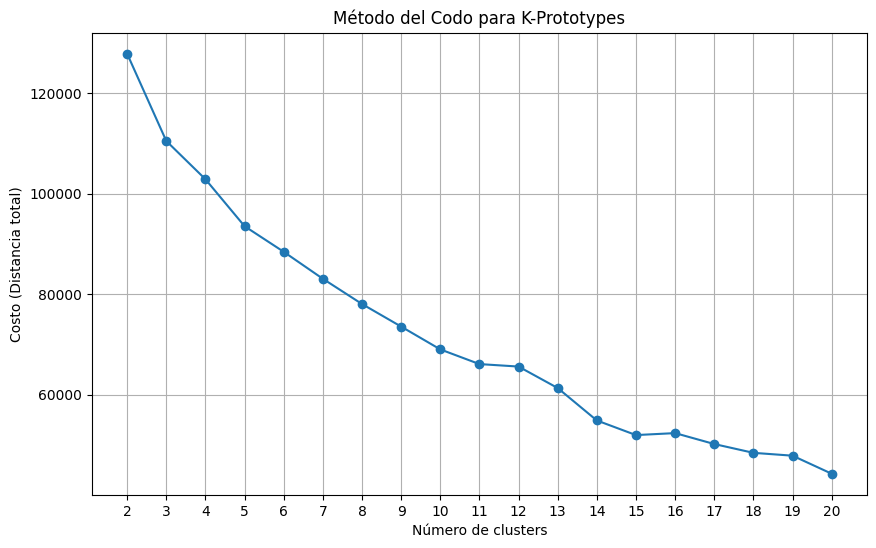

In [29]:
# 4. Calcular el costo (distancia) para distintos valores de K
costs = []
K_range = range(2, 21)  # de 1 a 20 clusters

for k in K_range:
    print(f"Entrenando modelo para k={k}")
    kproto = KPrototypes(n_clusters=k, init='Cao', gamma=gamma, n_init=5, verbose=0, random_state=42)
    clusters = kproto.fit_predict(data_matrix, categorical=cat_indices)
    costs.append(kproto.cost_)  # el costo total del clustering

# 5. Graficar el Codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, costs, marker='o')
plt.title('Método del Codo para K-Prototypes')
plt.xlabel('Número de clusters')
plt.ylabel('Costo (Distancia total)')
plt.grid(True)
plt.xticks(K_range)
plt.show()

In [30]:
# --- Paso 7: Calcular Silhouette Scores ---
silhouette_scores = []
cluster_counts = {}
rango_k = range(2, 21)

# Copia segura del DataFrame preprocesado
df_results = df_encoded.copy()
resultados = []

for k in rango_k:
    print(f"Entrenando modelo KPrototypes para k={k}...")
    
    # Entrenar KPrototypes
    kproto = KPrototypes(n_clusters=k, init='Cao', gamma=gamma, n_init=5, verbose=0, random_state=42)#n_clusters=k, init='Cao', verbose=0, random_state=42
    clusters = kproto.fit_predict(data_matrix, categorical=cat_indices)
    
    # Agregar cluster al DataFrame de resultados
    df_results[f'cluster_k_{k}'] = clusters
    
    # Agregar la columna del clúster al DataFrame
    df[f'cluster_k_{k}'] = clusters
    
    # Contar elementos por cluster
    cluster_counts[k] = pd.Series(clusters).value_counts().to_dict()
    
    # Copiar solo columnas originales codificadas
    df_silhouette = df_encoded.copy()
    
    # Calcular silhouette
    try:
        score = silhouette_score(df_silhouette, clusters, metric='euclidean')
    except Exception as e:
        print(f"Error al calcular silhouette para K={k}: {e}")
        score = np.nan

    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")
    print(pd.Series(clusters).value_counts())

    #resultados.append({
    #        'k': k,
    #        'Cluster': cluster,
    #        'Count': count,
    #        'Silhouette Score': silhouette_scores[k - rango_k.start]
     #   })

    # Convertir a DataFrame
tabla_resultados = pd.DataFrame(df_results)

# Mostrar la tabla de puntajes
resultado_silhouette = pd.DataFrame({'k': rango_k, 'Silhouette Score': silhouette_scores})
print(resultado_silhouette)

# Mostrar la tabla final
resultados = []
for k, clusters_dict in cluster_counts.items():
    for cluster, count in clusters_dict.items():
        resultados.append({
            'k': k,
            'Cluster': cluster,
            'Count': count,
            'Silhouette Score': silhouette_scores[k - rango_k.start]
        })

tabla_resultados = pd.DataFrame(resultados).sort_values(['k', 'Cluster']).reset_index(drop=True)

Entrenando modelo KPrototypes para k=2...
K=2, Silhouette Score=0.4320
0    9875
1     201
Name: count, dtype: int64
Entrenando modelo KPrototypes para k=3...
K=3, Silhouette Score=0.0827
0    7404
2    2473
1     199
Name: count, dtype: int64
Entrenando modelo KPrototypes para k=4...
K=4, Silhouette Score=0.0823
0    7320
3    2405
2     199
1     152
Name: count, dtype: int64
Entrenando modelo KPrototypes para k=5...
K=5, Silhouette Score=0.0593
4    5668
0    3486
3     575
2     197
1     150
Name: count, dtype: int64
Entrenando modelo KPrototypes para k=6...
K=6, Silhouette Score=0.0334
2    3796
0    3108
4    2271
1     554
3     197
5     150
Name: count, dtype: int64
Entrenando modelo KPrototypes para k=7...
K=7, Silhouette Score=0.0392
0    3778
4    3227
1    2139
2     546
5     171
3     149
6      66
Name: count, dtype: int64
Entrenando modelo KPrototypes para k=8...
K=8, Silhouette Score=0.0408
2    3824
1    3288
6    2145
3     582
0     111
7      64
4      55
5      

In [22]:
tabla_resultados

,k,Cluster,Count,Silhouette Score
0,2,0,201,0.431993
1,2,1,9875,0.431993
2,3,0,7412,0.082825
3,3,1,199,0.082825
4,3,2,2465,0.082825
...,...,...,...,...
204,20,15,788,0.000044
205,20,16,867,0.000044
206,20,17,7,0.000044
207,20,18,66,0.000044


In [121]:
tabla_resultados.to_csv(ruta+'resultado_cluster_kprototype_cao_gamma_masnumericas.csv', sep='|', encoding='utf-8', decimal=',')

In [33]:
df.to_csv(ruta+'df_kprototype.csv', sep='|', encoding='utf-8', decimal=',')

In [13]:
# Reducimos dimensiones con t-SNE 
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(df_cat_encoding)

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10,11,12,13,14,15,16,17,18,19,20]
#k_values = [2]
for k in k_values:
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0, random_state=42)
    clusters = kproto.fit_predict(data_matrix, categorical=cat_indices)
    #labels = kmeans.fit_predict(df_cat_encoding)
    
    plt.figure(figsize=(7,4))  # un poco más ancho para dar espacio a la leyenda
    cmap = plt.get_cmap('tab10')
    
    for cluster_id in range(k):
        idx = labels == cluster_id
        count = idx.sum()
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                    color=cmap(cluster_id),
                    label=f'Cluster {cluster_id} (n={count})',
                    alpha=0.7,
                    s=50)
    
    plt.title(f'Clusters visualizados con t-SNE para k={k}')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.grid(True)

    # Leyenda fuera del gráfico
    plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
   
    
    plt.tight_layout()  # Ajusta el espacio para evitar que se corte la leyenda
    plt.savefig(ruta+f'clusters_tsne_k{k}.png', dpi=300, bbox_inches='tight')
    plt.show()

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


### Crear perfiles de los grupos

In [36]:
df_perfil = df[['CUIT','Nombre','FechaPreinscripcion','Estado','TipoSocietario','anio_preinscripcion','cant_procesos_adjudicado','monto_total_adjudicado','antiguedad','provincia','cant_socios','cant_apercibimientos','cant_suspensiones','cant_antecedentes','cant_Apoderado','cant_representante','cant_autenticado','cant_noAutenticado','cant_sinMontoLimite','cant_MontoLimite','total_articulos_provee','cluster_k_4']]


In [37]:
grupo1 = df_perfil[df_perfil['cluster_k_4'] == 0].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo1, title="Informe de análisis exploratorio kprototype grupo 1", explorative=True)
profile.to_file(ruta+"informe_perfil_kprototype_g1.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/22 [00:00<?, ?it/s]
%|███▊                                                                               | 1/22 [00:00<00:05,  3.72it/s]
%|███████▌                                                                           | 2/22 [00:00<00:03,  5.29it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 33.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [39]:
grupo2= df_perfil[df_perfil['cluster_k_4'] == 1].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo2, title="Informe de análisis exploratorio kprototype grupo 2", explorative=True)
profile.to_file(ruta+"informe_perfil_kprototype_g2.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/22 [00:00<?, ?it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 65.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [40]:
grupo3 = df_perfil[df_perfil['cluster_k_4'] == 2].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo3, title="Informe de análisis exploratorio kprototype grupo 3", explorative=True)
profile.to_file(ruta+"informe_perfil_kprototype_g3.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/22 [00:00<?, ?it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 93.50it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [41]:
grupo4 = df_perfil[df_perfil['cluster_k_4'] == 3].copy()
# Crear el perfil grupo 1
profile = ProfileReport(grupo4, title="Informe de análisis exploratorio kprototype grupo 4", explorative=True)
profile.to_file(ruta+"informe_perfil_kprototype_g4.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/22 [00:00<?, ?it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 53.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Gráfico de barras superpuestas

In [42]:
# Conteos en porcentaje para el original
def graficar_barras_comparacion(df, columna, condicion_filtrado, titulo, grupo):
    """
    Grafica la distribución porcentual de una variable categórica en dos universos:
    - Todo el DataFrame
    - Solo los casos que cumplen una condición dada
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con los datos.
    columna : str
        Nombre de la columna categórica a graficar.
    titulo : str
        Título para el gráfico.
   
    """
    
    # Conteo porcentual en el DataFrame original
    conteo_original = df[columna].value_counts(normalize=True) * 100
    
    # Filtrar según la condición
    df_filtrado = df[condicion_filtrado(df)]
    conteo_filtrado = df_filtrado[columna].value_counts(normalize=True) * 100
    
    # Unificar índices para que ambas series tengan las mismas categorías
    categorias = conteo_original.index.union(conteo_filtrado.index)
    conteo_original = conteo_original.reindex(categorias, fill_value=0)
    conteo_filtrado = conteo_filtrado.reindex(categorias, fill_value=0)
    
    # Crear gráfico
    plt.figure(figsize=(6, 4))
    plt.bar(conteo_original.index, conteo_original.values, color='skyblue', alpha=0.6, label='Universo')
    plt.bar(conteo_filtrado.index, conteo_filtrado.values, facecolor='none', edgecolor='red', linewidth=2, label=grupo)
    
    plt.title(titulo, fontsize=11)
    plt.xlabel(columna, fontsize=9)
    plt.ylabel('Porcentaje de Casos', fontsize=9)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=9)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

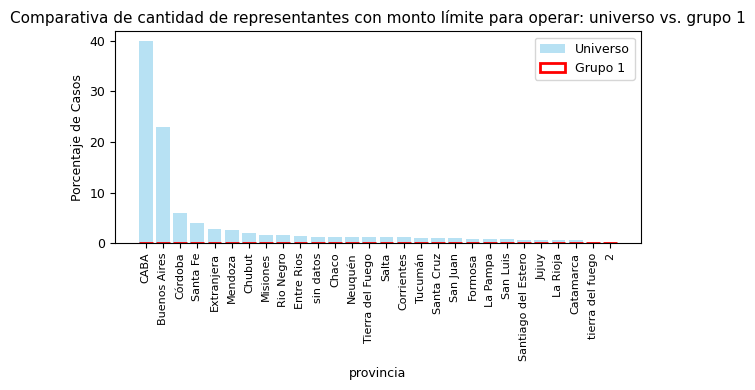

In [145]:
graficar_barras_comparacion(
    df=df,
    columna='provincia',
    condicion_filtrado=lambda df: df['cluster_k_4'] == 4,
    titulo='Comparativa de cantidad de representantes con monto límite para operar: universo vs. grupo 1',
    grupo='Grupo 1'
)

In [54]:
# Acortar los nombres 
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Persona Física Extranjero No Residente', 'PF Extranjero No Residente', regex=False)
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Persona Jurídica Extranjero Sin Sucursal', 'PJ Extranjero Sin Sucursal', regex=False)
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Sociedad Responsabilidad Limitada', 'S.R.L', regex=False)
df['TipoSocietario'] = df['TipoSocietario'].str.replace('Talleres protegidos de Producción', 'Talleres protegidos', regex=False)

In [68]:
df['provincia'] = df['provincia'].str.replace('Ciudad Autónoma de Buenos Aires', 'CABA', regex=False)

In [135]:
df['cant_MontoLimite'] = df['cant_MontoLimite'].astype(str)

In [80]:
def limpiar_rango(val):
    # Reemplaza todos los números con punto decimal por la parte antes del punto
    matches = re.findall(r'\d+,\d+', val)
  #  return re.sub(r'(\d+)\,\d+', r'\1', val)
    for match in matches:
        # Parte entera antes de la coma
        entero = match.split(',')[0]
        # Agrega punto como separador de miles
        entero_formateado = f"{int(entero):,}".replace(",", ".")
        # Reemplaza el número original con el formateado
        val = val.replace(match, entero_formateado)
    return val

In [81]:
df['dmonto_total_adjudicado'] = df['dmonto_total_adjudicado'].str.replace('.', ',', regex=False)
df['dmonto_total_adjudicado'] = df['dmonto_total_adjudicado'].str.replace('-0.001', '0', regex=False)
# Aplica la función a la columna deseada
df['dmonto_total_adjudicado'] = df['dmonto_total_adjudicado'].astype(str).apply(limpiar_rango)
#df['dmonto_total_adjudicado'] = df['dmonto_total_adjudicado'].str.split(',').str[0]
